In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/titanic.csv")

print("Dataset loaded successfully!")
print("Rows and columns:", df.shape)

df.head()

Dataset loaded successfully!
Rows and columns: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
# Descriptive Statistics

print("Descriptive Statistics:")
df.describe()

Descriptive Statistics:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [3]:
# Mean, Median and Mode

print("Mean Age:", df["Age"].mean())
print("Median Age:", df["Age"].median())
print("Mode Age:", df["Age"].mode()[0])

print("\nMean Fare:", df["Fare"].mean())
print("Median Fare:", df["Fare"].median())
print("Mode Fare:", df["Fare"].mode()[0])

Mean Age: 29.69911764705882
Median Age: 28.0
Mode Age: 24.0

Mean Fare: 32.204207968574636
Median Fare: 14.4542
Mode Fare: 8.05


In [4]:
# Variance, Standard Deviation, Skewness and Kurtosis

age = df["Age"].dropna()

print("Age Variance:", age.var())
print("Age Standard Deviation:", age.std())
print("Age Skewness:", age.skew())
print("Age Kurtosis:", age.kurt())

Age Variance: 211.01912474630805
Age Standard Deviation: 14.526497332334042
Age Skewness: 0.38910778230082693
Age Kurtosis: 0.1782741536421022


In [5]:
# Correlation Analysis

correlation = df[["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]].corr()

print("Correlation Matrix:")
display(correlation)

Correlation Matrix:


,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


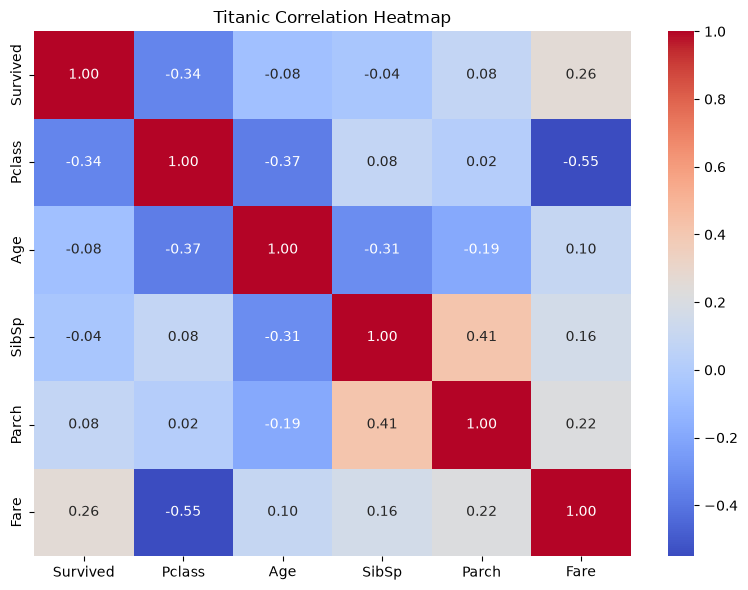

In [6]:
# Correlation Heatmap

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Titanic Correlation Heatmap")
plt.tight_layout()
plt.show()

In [7]:
from scipy.stats import ttest_ind

survived_fare = df[df["Survived"] == 1]["Fare"].dropna()
not_survived_fare = df[df["Survived"] == 0]["Fare"].dropna()

t_stat, p_value = ttest_ind(survived_fare, not_survived_fare)

print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Result: The difference is statistically significant.")
else:
    print("Result: The difference is not statistically significant.")

T-statistic: 7.939191660871055
P-value: 6.1201893419242075e-15
Result: The difference is statistically significant.


In [8]:
from scipy import stats

fare = df["Fare"].dropna()

mean_fare = fare.mean()
standard_error = fare.sem()

confidence_interval = stats.t.interval(
    confidence=0.95,
    df=len(fare) - 1,
    loc=mean_fare,
    scale=standard_error
)

print("Mean Fare:", mean_fare)
print("95% Confidence Interval:", confidence_interval)

Mean Fare: 32.204207968574636
95% Confidence Interval: (np.float64(28.93683123456733), np.float64(35.47158470258194))


In [9]:
# Time Series Analysis

df["Date"] = pd.date_range(start="2020-01-01", periods=len(df), freq="D")
df_time = df.set_index("Date")

# Daily average fare
daily_fare = df_time["Fare"].resample("D").mean()

print("Daily Average Fare:")
print(daily_fare.head(10))

Daily Average Fare:
Date
2020-01-01     7.2500
2020-01-02    71.2833
2020-01-03     7.9250
2020-01-04    53.1000
2020-01-05     8.0500
2020-01-06     8.4583
2020-01-07    51.8625
2020-01-08    21.0750
2020-01-09    11.1333
2020-01-10    30.0708
Freq: D, Name: Fare, dtype: float64


In [10]:
# T-Test: Compare Fare by Passenger Class

from scipy.stats import ttest_ind

class1 = df[df["Pclass"] == 1]["Fare"].dropna()
class3 = df[df["Pclass"] == 3]["Fare"].dropna()

t_stat, p_value = ttest_ind(class1, class3, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Result: Significant difference between Class 1 and Class 3 fares.")
else:
    print("Result: No significant difference between Class 1 and Class 3 fares.")

T-statistic: 13.150240604491971
P-value: 1.659990202162316e-29
Result: Significant difference between Class 1 and Class 3 fares.


In [11]:
# Chi-Square Test: Gender vs Survival

from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df["Sex"], df["Survived"])

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square Statistic:", chi2)
print("P-value:", p_value)

if p_value < 0.05:
    print("Result: Gender and survival are significantly associated.")
else:
    print("Result: No significant association between gender and survival.")

Chi-Square Statistic: 260.71702016732104
P-value: 1.1973570627755645e-58
Result: Gender and survival are significantly associated.


In [12]:
# ANOVA Test: Fare by Passenger Class

from scipy.stats import f_oneway

class1 = df[df["Pclass"] == 1]["Fare"].dropna()
class2 = df[df["Pclass"] == 2]["Fare"].dropna()
class3 = df[df["Pclass"] == 3]["Fare"].dropna()

f_stat, p_value = f_oneway(class1, class2, class3)

print("ANOVA F-statistic:", f_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Result: Fare differs significantly between passenger classes.")
else:
    print("Result: No significant difference in fare between passenger classes.")

ANOVA F-statistic: 242.34415651744814
P-value: 1.031376320913912e-84
Result: Fare differs significantly between passenger classes.


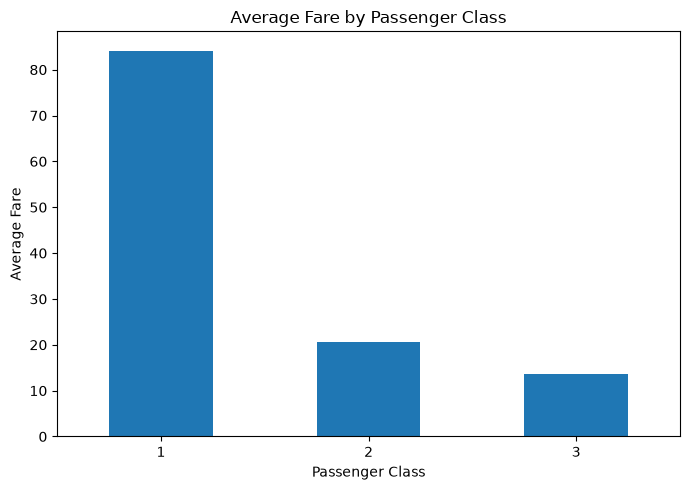

In [13]:
# Average Fare by Passenger Class

avg_fare = df.groupby("Pclass")["Fare"].mean()

plt.figure(figsize=(7, 5))
avg_fare.plot(kind="bar")

plt.title("Average Fare by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Average Fare")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

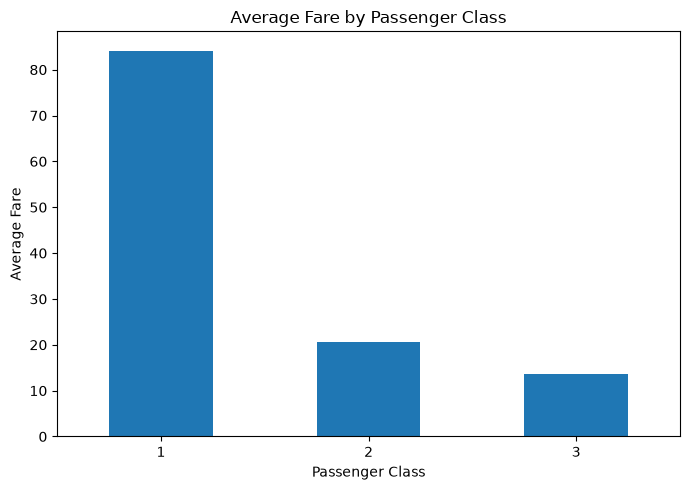

In [14]:
# Save Average Fare graph

avg_fare = df.groupby("Pclass")["Fare"].mean()

plt.figure(figsize=(7, 5))
avg_fare.plot(kind="bar")

plt.title("Average Fare by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Average Fare")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("../reports/average_fare_by_class.png", dpi=300)
plt.show()

In [15]:
# Create simple monthly sales data

dates = pd.date_range(start="2023-01-01", periods=36, freq="MS")

sales = [
    12000, 12500, 13000, 12800, 13500, 14000,
    14500, 15000, 14800, 15500, 16000, 16500,
    15800, 16200, 17000, 17500, 17200, 18000,
    18500, 19000, 18800, 19500, 20000, 20500,
    19800, 20200, 21000, 21500, 21200, 22000,
    22500, 23000, 22800, 23500, 24000, 24500
]

sales_df = pd.DataFrame({
    "Date": dates,
    "Sales": sales
})

sales_df.set_index("Date", inplace=True)

sales_df.head()

,Sales
Date,
2023-01-01,12000
2023-02-01,12500
2023-03-01,13000
2023-04-01,12800
2023-05-01,13500


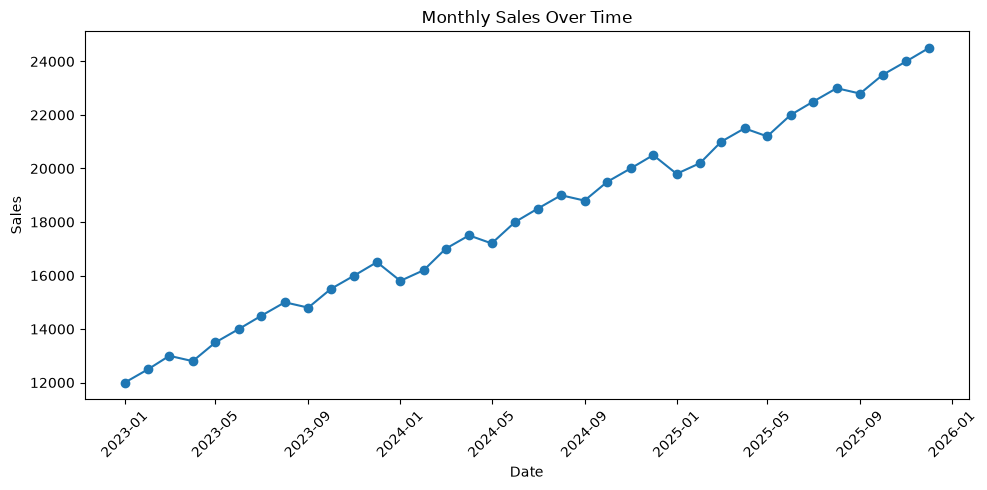

In [16]:
# Sales over time

plt.figure(figsize=(10, 5))

plt.plot(
    sales_df.index,
    sales_df["Sales"],
    marker="o"
)

plt.title("Monthly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:
# Quarterly average sales

quarterly_sales = sales_df["Sales"].resample("3ME").mean()

print("Quarterly Average Sales:")
print(quarterly_sales)

Quarterly Average Sales:
Date
2023-01-31    12000.000000
2023-04-30    12766.666667
2023-07-31    14000.000000
2023-10-31    15100.000000
2024-01-31    16100.000000
2024-04-30    16900.000000
2024-07-31    17900.000000
2024-10-31    19100.000000
2025-01-31    20100.000000
2025-04-30    20900.000000
2025-07-31    21900.000000
2025-10-31    23100.000000
2026-01-31    24250.000000
Freq: 3ME, Name: Sales, dtype: float64


In [18]:
# 3-Month Moving Average

sales_df["Moving_Average"] = sales_df["Sales"].rolling(window=3).mean()

print(sales_df[["Sales", "Moving_Average"]].head(10))

            Sales  Moving_Average
Date                             
2023-01-01  12000             NaN
2023-02-01  12500             NaN
2023-03-01  13000    12500.000000
2023-04-01  12800    12766.666667
2023-05-01  13500    13100.000000
2023-06-01  14000    13433.333333
2023-07-01  14500    14000.000000
2023-08-01  15000    14500.000000
2023-09-01  14800    14766.666667
2023-10-01  15500    15100.000000


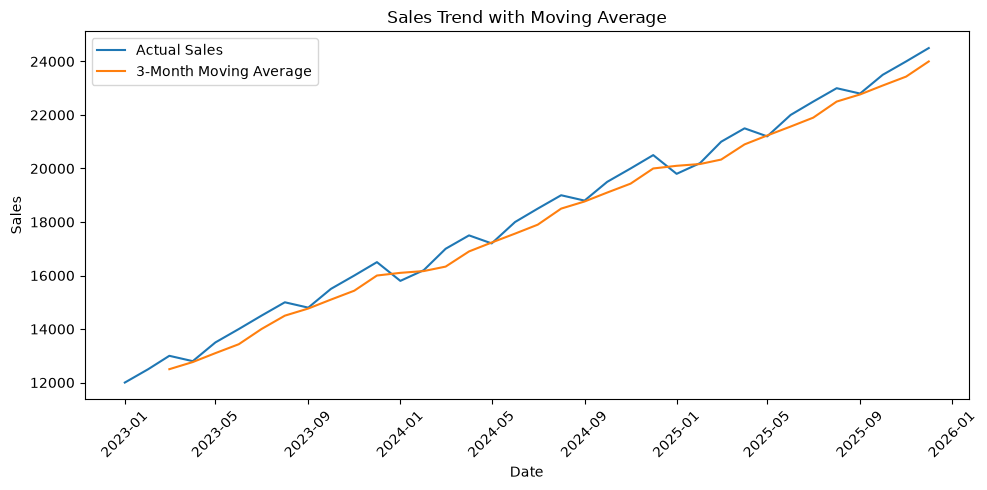

In [19]:
# Sales with 3-Month Moving Average

plt.figure(figsize=(10, 5))

plt.plot(
    sales_df.index,
    sales_df["Sales"],
    label="Actual Sales"
)

plt.plot(
    sales_df.index,
    sales_df["Moving_Average"],
    label="3-Month Moving Average"
)

plt.title("Sales Trend with Moving Average")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
# Exponential Smoothing

from statsmodels.tsa.holtwinters import ExponentialSmoothing

model = ExponentialSmoothing(
    sales_df["Sales"],
    trend="add"
)

fit = model.fit()

sales_df["Exponential_Smoothing"] = fit.fittedvalues

print(sales_df[["Sales", "Exponential_Smoothing"]].head(10))

            Sales  Exponential_Smoothing
Date                                    
2023-01-01  12000           12208.407592
2023-02-01  12500           12549.038251
2023-03-01  13000           12889.668913
2023-04-01  12800           13230.299577
2023-05-01  13500           13570.930233
2023-06-01  14000           13911.560895
2023-07-01  14500           14252.191559
2023-08-01  15000           14592.822225
2023-09-01  14800           14933.452894
2023-10-01  15500           15274.083554


c:\Users\UJJWAL\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


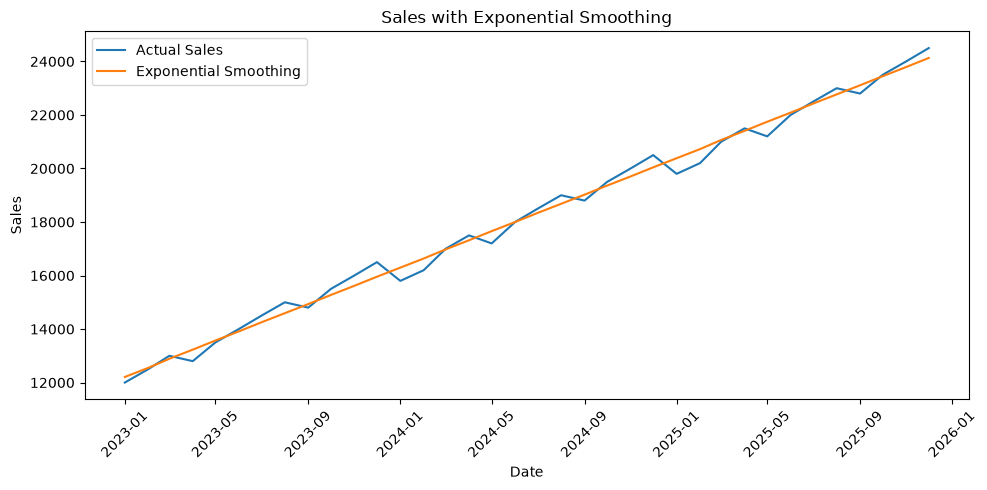

In [21]:
# Exponential Smoothing Graph

plt.figure(figsize=(10, 5))

plt.plot(
    sales_df.index,
    sales_df["Sales"],
    label="Actual Sales"
)

plt.plot(
    sales_df.index,
    sales_df["Exponential_Smoothing"],
    label="Exponential Smoothing"
)

plt.title("Sales with Exponential Smoothing")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
# Augmented Dickey-Fuller Test

from statsmodels.tsa.stattools import adfuller

result = adfuller(sales_df["Sales"])

print("ADF Statistic:", result[0])
print("P-value:", result[1])

if result[1] < 0.05:
    print("Result: The time series is stationary.")
else:
    print("Result: The time series is not stationary.")

ADF Statistic: 0.07901931017780857
P-value: 0.964599105372215
Result: The time series is not stationary.


In [23]:
# ARIMA Forecast

from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(sales_df["Sales"], order=(1, 1, 1))
model_fit = model.fit()

forecast = model_fit.forecast(steps=6)

print("Next 6 Months Forecast:")
print(forecast)

Next 6 Months Forecast:
2026-01-01    24850.529828
2026-02-01    25201.056333
2026-03-01    25551.579513
2026-04-01    25902.099371
2026-05-01    26252.615905
2026-06-01    26603.129115
Freq: MS, Name: predicted_mean, dtype: float64


c:\Users\UJJWAL\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\UJJWAL\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\UJJWAL\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\UJJWAL\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\User

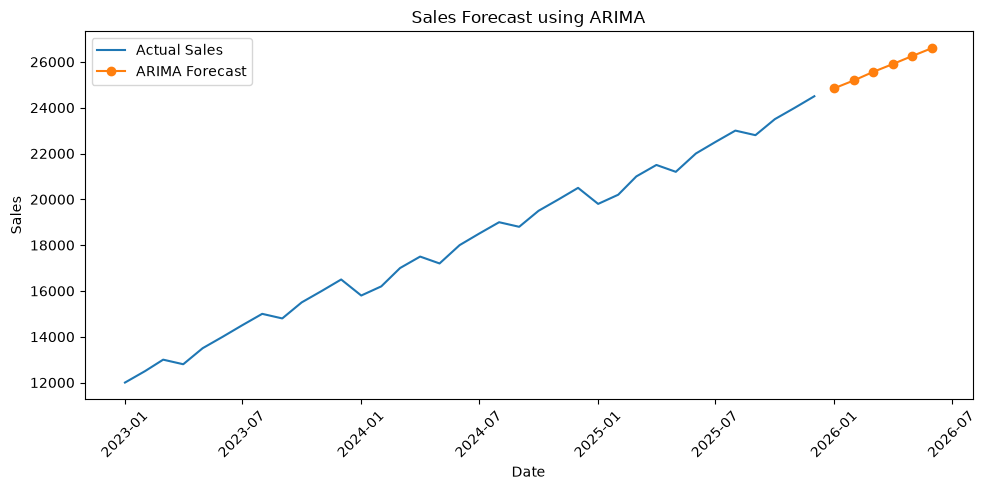

In [24]:
# ARIMA Forecast Graph

plt.figure(figsize=(10, 5))

plt.plot(
    sales_df.index,
    sales_df["Sales"],
    label="Actual Sales"
)

forecast_dates = pd.date_range(
    start=sales_df.index[-1] + pd.offsets.MonthBegin(1),
    periods=6,
    freq="MS"
)

plt.plot(
    forecast_dates,
    forecast.values,
    marker="o",
    label="ARIMA Forecast"
)

plt.title("Sales Forecast using ARIMA")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
# Forecast Accuracy

from sklearn.metrics import mean_absolute_error, mean_squared_error

# Use the last 6 actual months for testing
actual = sales_df["Sales"].iloc[-6:]

# Forecast the same 6 months
test_forecast = model_fit.forecast(steps=6)

mae = mean_absolute_error(actual, test_forecast)
rmse = np.sqrt(mean_squared_error(actual, test_forecast))
mape = np.mean(np.abs((actual.values - test_forecast.values) / actual.values)) * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape, "%")

MAE: 2343.5016773609764
RMSE: 2352.5993122660643
MAPE: 10.046123349599204 %


In [26]:
# Prepare data for Customer Segmentation

features = df[["Age", "Fare", "Pclass"]].dropna()

print("Data prepared for clustering:")
print(features.head())
print("\nNumber of records:", len(features))

Data prepared for clustering:
    Age     Fare  Pclass
0  22.0   7.2500       3
1  38.0  71.2833       1
2  26.0   7.9250       3
3  35.0  53.1000       1
4  35.0   8.0500       3

Number of records: 714


In [27]:
# Standardize the clustering data

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(features)

print("Data standardized successfully!")
print(X_scaled[:5])

Data standardized successfully!
[[-0.53037664 -0.51897787  0.91123237]
 [ 0.57183099  0.69189675 -1.47636364]
 [-0.25482473 -0.50621356  0.91123237]
 [ 0.36516706  0.34804915 -1.47636364]
 [ 0.36516706 -0.5038498   0.91123237]]


In [28]:
# K-Means Clustering - 5 Clusters

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

clusters = kmeans.fit_predict(X_scaled)

features["Cluster"] = clusters

print("5 clusters created successfully!")
print(features["Cluster"].value_counts().sort_index())

5 clusters created successfully!
Cluster
0    230
1    100
2    266
3     18
4    100
Name: count, dtype: int64


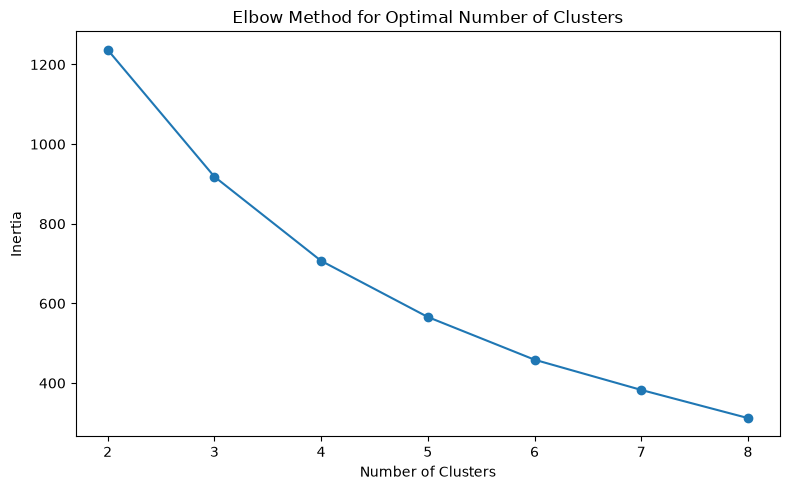

In [29]:
# Elbow Method

inertia = []

for k in range(2, 9):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 9), inertia, marker="o")

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.xticks(range(2, 9))
plt.tight_layout()
plt.show()

In [30]:
# Silhouette Score

from sklearn.metrics import silhouette_score

silhouette = silhouette_score(X_scaled, clusters)

print("Silhouette Score:", silhouette)

Silhouette Score: 0.35914594705942293


In [31]:
# PCA - Reduce to 2 Dimensions

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("PCA completed successfully!")
print("Explained variance:", pca.explained_variance_ratio_)

PCA completed successfully!
Explained variance: [0.57087687 0.30387567]


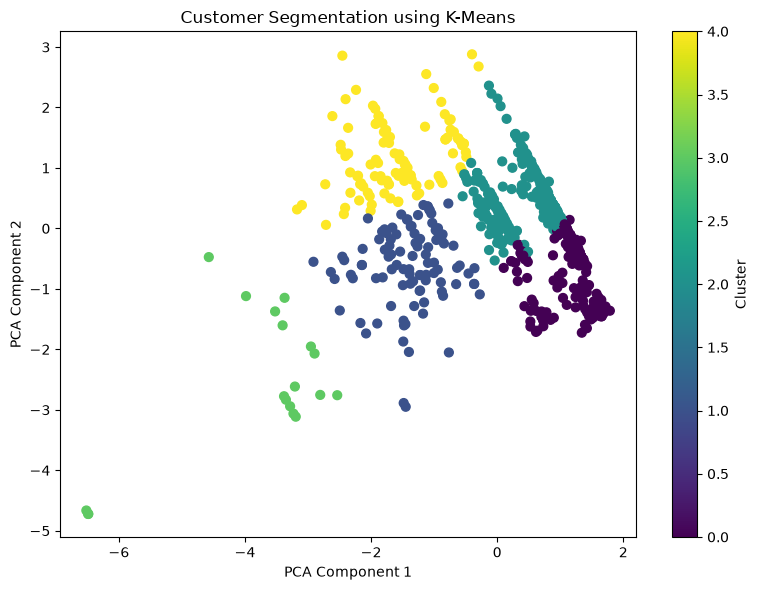

In [32]:
# PCA Cluster Visualization

plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    cmap="viridis",
    s=40
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label="Cluster")
plt.tight_layout()
plt.show()

In [38]:
# Step 26 - Customer Segment Profile

# Calculate average values for each customer segment
cluster_profile = features.groupby("Cluster")[["Age", "Fare", "Pclass"]].mean().round(2)

print("Customer Segment Profile:")
display(cluster_profile)

Customer Segment Profile:


,Age,Fare,Pclass
Cluster,,,
0,15.62,15.23,2.84
1,28.06,77.33,1.06
2,33.55,15.05,2.60
3,31.17,285.38,1.00
4,53.20,43.95,1.28


In [39]:
# Step 27 - Count Customers in Each Segment

cluster_counts = features["Cluster"].value_counts().sort_index()

print("Number of customers in each segment:")
print(cluster_counts)

Number of customers in each segment:
Cluster
0    230
1    100
2    266
3     18
4    100
Name: count, dtype: int64


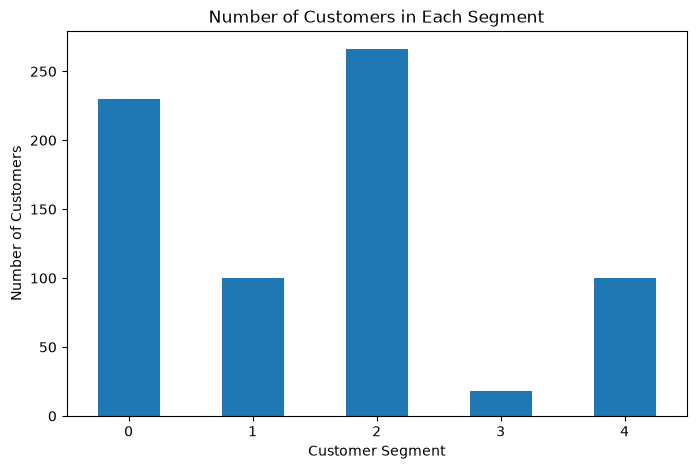

In [40]:
# Step 28 - Visualize Customer Segments

plt.figure(figsize=(8, 5))

cluster_counts.plot(kind="bar")

plt.title("Number of Customers in Each Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.show()

In [41]:
# Step 29 - Detailed Customer Segment Profile

segment_profile = features.groupby("Cluster").agg(
    Average_Age=("Age", "mean"),
    Average_Fare=("Fare", "mean"),
    Average_Pclass=("Pclass", "mean"),
    Number_of_Customers=("Cluster", "size")
).round(2)

print("Customer Segment Characteristics:")
display(segment_profile)

Customer Segment Characteristics:


,Average_Age,Average_Fare,Average_Pclass,Number_of_Customers
Cluster,,,,
0,15.62,15.23,2.84,230
1,28.06,77.33,1.06,100
2,33.55,15.05,2.60,266
3,31.17,285.38,1.00,18
4,53.20,43.95,1.28,100


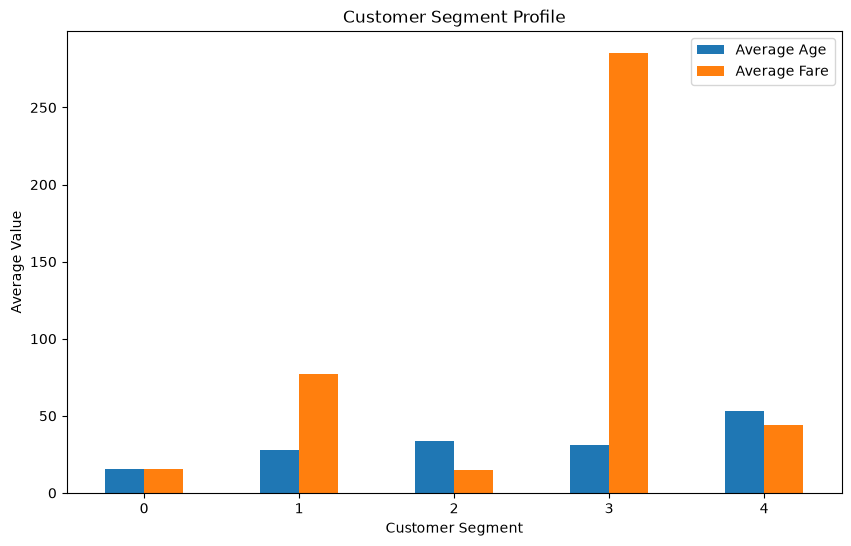

In [42]:
# Step 30 - Segment Profile Visualization

segment_profile[["Average_Age", "Average_Fare"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Customer Segment Profile")
plt.xlabel("Customer Segment")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.legend(["Average Age", "Average Fare"])

plt.show()

In [43]:
# Step 31 - Final Segment Summary

print("FINAL CUSTOMER SEGMENT SUMMARY")
print("=" * 50)

for cluster, row in segment_profile.iterrows():
    print(f"\nCluster {cluster}")
    print(f"  Average Age: {row['Average_Age']}")
    print(f"  Average Fare: {row['Average_Fare']}")
    print(f"  Average Passenger Class: {row['Average_Pclass']}")
    print(f"  Number of Passengers: {int(row['Number_of_Customers'])}")

FINAL CUSTOMER SEGMENT SUMMARY

Cluster 0
  Average Age: 15.62
  Average Fare: 15.23
  Average Passenger Class: 2.84
  Number of Passengers: 230

Cluster 1
  Average Age: 28.06
  Average Fare: 77.33
  Average Passenger Class: 1.06
  Number of Passengers: 100

Cluster 2
  Average Age: 33.55
  Average Fare: 15.05
  Average Passenger Class: 2.6
  Number of Passengers: 266

Cluster 3
  Average Age: 31.17
  Average Fare: 285.38
  Average Passenger Class: 1.0
  Number of Passengers: 18

Cluster 4
  Average Age: 53.2
  Average Fare: 43.95
  Average Passenger Class: 1.28
  Number of Passengers: 100


In [44]:
# Step 32 - Segment Interpretation

segment_labels = {
    0: "Segment 0",
    1: "Segment 1",
    2: "Segment 2",
    3: "Segment 3",
    4: "Segment 4"
}

segment_profile["Segment_Name"] = segment_profile.index.map(segment_labels)

display(segment_profile)

,Average_Age,Average_Fare,Average_Pclass,Number_of_Customers,Segment_Name
Cluster,,,,,
0,15.62,15.23,2.84,230,Segment 0
1,28.06,77.33,1.06,100,Segment 1
2,33.55,15.05,2.60,266,Segment 2
3,31.17,285.38,1.00,18,Segment 3
4,53.20,43.95,1.28,100,Segment 4


In [45]:
# Step 33 - Recommendations for Each Segment

recommendations = {
    0: "Focus on improving engagement and providing suitable offers.",
    1: "Provide affordable options and promotional offers.",
    2: "Provide personalized services and loyalty benefits.",
    3: "Use targeted promotions to increase engagement.",
    4: "Provide balanced offers based on customer characteristics."
}

segment_profile["Recommendation"] = segment_profile.index.map(recommendations)

display(
    segment_profile[
        ["Average_Age", "Average_Fare", "Average_Pclass",
         "Number_of_Customers", "Segment_Name", "Recommendation"]
    ]
)

,Average_Age,Average_Fare,Average_Pclass,Number_of_Customers,Segment_Name,Recommendation
Cluster,,,,,,
0,15.62,15.23,2.84,230,Segment 0,Focus on improving engagement and providing su...
1,28.06,77.33,1.06,100,Segment 1,Provide affordable options and promotional off...
2,33.55,15.05,2.60,266,Segment 2,Provide personalized services and loyalty bene...
3,31.17,285.38,1.00,18,Segment 3,Use targeted promotions to increase engagement.
4,53.20,43.95,1.28,100,Segment 4,Provide balanced offers based on customer char...


In [46]:
# Step 34 - Prepare Data for Predictive Modeling

# Select features and target
model_data = df[["Age", "Fare", "Pclass", "Survived"]].dropna()

# Features (input variables)
X_model = model_data[["Age", "Fare", "Pclass"]]

# Target (what we want to predict)
y_model = model_data["Survived"]

print("Features:")
display(X_model.head())

print("Target:")
display(y_model.head())

print("Total records:", len(model_data))

Features:


,Age,Fare,Pclass
0,22.0,7.2500,3
1,38.0,71.2833,1
2,26.0,7.9250,3
3,35.0,53.1000,1
4,35.0,8.0500,3


Target:


0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

Total records: 714


In [47]:
# Step 35 - Train Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y_model,
    test_size=0.2,
    random_state=42,
    stratify=y_model
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 571
Testing records: 143


In [58]:
# Step 50 - Linear Regression

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Features and numeric target
X_reg = df[["Age", "Pclass"]]
y_reg = df["Fare"]

# Remove missing values
reg_data = pd.concat([X_reg, y_reg], axis=1).dropna()

X_reg = reg_data[["Age", "Pclass"]]
y_reg = reg_data["Fare"]

# Train-test split
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

# Create and train the model
linear_model = LinearRegression()
linear_model.fit(X_reg_train, y_reg_train)

# Make predictions
y_reg_pred = linear_model.predict(X_reg_test)

# Evaluate
r2 = r2_score(y_reg_test, y_reg_pred)
mae_reg = mean_absolute_error(y_reg_test, y_reg_pred)
rmse_reg = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))

print("Linear Regression Results")
print("=" * 35)
print("R²   :", round(r2, 3))
print("MAE  :", round(mae_reg, 3))
print("RMSE :", round(rmse_reg, 3))

Linear Regression Results
R²   : 0.192
MAE  : 24.323
RMSE : 58.008


In [48]:
# Step 36 - Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Create the model
logistic_model = LogisticRegression(max_iter=1000)

# Train the model
logistic_model.fit(X_train, y_train)

# Make predictions
y_pred_logistic = logistic_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred_logistic)
precision = precision_score(y_test, y_pred_logistic)
recall = recall_score(y_test, y_pred_logistic)
f1 = f1_score(y_test, y_pred_logistic)

print("Logistic Regression Results")
print("=" * 35)
print("Accuracy :", round(accuracy, 3))
print("Precision:", round(precision, 3))
print("Recall   :", round(recall, 3))
print("F1-Score :", round(f1, 3))

Logistic Regression Results
Accuracy : 0.692
Precision: 0.659
Recall   : 0.5
F1-Score : 0.569


In [49]:
# Step 37 - Decision Tree

from sklearn.tree import DecisionTreeClassifier

# Create the model
tree_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

# Train the model
tree_model.fit(X_train, y_train)

# Make predictions
y_pred_tree = tree_model.predict(X_test)

# Evaluate the model
tree_accuracy = accuracy_score(y_test, y_pred_tree)
tree_precision = precision_score(y_test, y_pred_tree)
tree_recall = recall_score(y_test, y_pred_tree)
tree_f1 = f1_score(y_test, y_pred_tree)

print("Decision Tree Results")
print("=" * 35)
print("Accuracy :", round(tree_accuracy, 3))
print("Precision:", round(tree_precision, 3))
print("Recall   :", round(tree_recall, 3))
print("F1-Score :", round(tree_f1, 3))

Decision Tree Results
Accuracy : 0.692
Precision: 0.635
Recall   : 0.569
F1-Score : 0.6


In [50]:
# Step 38 - Compare Predictive Models

model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [accuracy, tree_accuracy],
    "Precision": [precision, tree_precision],
    "Recall": [recall, tree_recall],
    "F1-Score": [f1, tree_f1]
})

model_comparison = model_comparison.round(3)

print("Model Comparison")
display(model_comparison)

Model Comparison


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.692,0.659,0.500,0.569
1,Decision Tree,0.692,0.635,0.569,0.600


In [51]:
# Step 39 - Feature Importance

feature_importance = pd.DataFrame({
    "Feature": X_model.columns,
    "Importance": tree_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).round(3)

print("Feature Importance")
display(feature_importance)

Feature Importance


,Feature,Importance
2,Pclass,0.444
0,Age,0.286
1,Fare,0.270


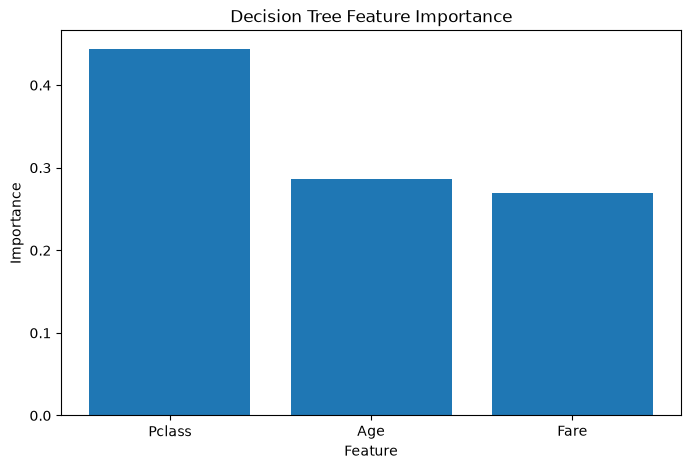

In [52]:
# Step 40 - Feature Importance Visualization

plt.figure(figsize=(8, 5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Decision Tree Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")

plt.show()

In [53]:
# Step 41 - ROC-AUC Evaluation

from sklearn.metrics import roc_auc_score

# Probability predictions
y_prob_logistic = logistic_model.predict_proba(X_test)[:, 1]
y_prob_tree = tree_model.predict_proba(X_test)[:, 1]

# Calculate ROC-AUC
roc_auc_logistic = roc_auc_score(y_test, y_prob_logistic)
roc_auc_tree = roc_auc_score(y_test, y_prob_tree)

print("ROC-AUC Results")
print("=" * 35)
print("Logistic Regression:", round(roc_auc_logistic, 3))
print("Decision Tree      :", round(roc_auc_tree, 3))

ROC-AUC Results
Logistic Regression: 0.733
Decision Tree      : 0.652


In [54]:
# Step 42 - Final Model Comparison

final_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [accuracy, tree_accuracy],
    "Precision": [precision, tree_precision],
    "Recall": [recall, tree_recall],
    "F1-Score": [f1, tree_f1],
    "ROC-AUC": [roc_auc_logistic, roc_auc_tree]
})

final_comparison = final_comparison.round(3)

print("FINAL MODEL COMPARISON")
display(final_comparison)

FINAL MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.692,0.659,0.500,0.569,0.733
1,Decision Tree,0.692,0.635,0.569,0.600,0.652


In [55]:
# Step 43 - Best Model

if roc_auc_logistic >= roc_auc_tree:
    best_model = "Logistic Regression"
    best_score = roc_auc_logistic
else:
    best_model = "Decision Tree"
    best_score = roc_auc_tree

print("Best Model:", best_model)
print("ROC-AUC:", round(best_score, 3))

Best Model: Logistic Regression
ROC-AUC: 0.733


## Model Limitations

- The models were trained using only Age, Fare, and Pclass.
- Other potentially useful passenger information was not included.
- The dataset contains historical Titanic passenger data, so the results cannot be directly generalized to other populations.
- Model performance depends on the quality and size of the available data.
- Logistic Regression assumes a relatively simple relationship between the input variables and the target.
- Decision Tree performance can change depending on the tree parameters.
- The models show associations in the dataset and should not be interpreted as proof of causation.

# Task 4 - Final Summary

## 1. Statistical Analysis
Performed descriptive and statistical analysis to understand the dataset and relationships between variables.

## 2. Time Series Analysis
Performed time-series analysis and forecasting to identify trends and evaluate forecast performance.

## 3. Customer Segmentation
Applied StandardScaler and K-Means clustering to divide the data into 5 segments. PCA was used to visualize the clusters.

## 4. Predictive Modeling
Built two classification models:
- Logistic Regression
- Decision Tree

The models were evaluated using:
- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC

Feature importance was also analyzed using the Decision Tree model.

## 5. Key Findings
The analysis identified meaningful differences between the five clusters and showed that machine learning models can be used to predict the target variable based on selected features.

## 6. Limitations
The analysis was based on a limited number of features and a historical dataset. Therefore, the results should not be generalized beyond the dataset without further validation.

In [56]:
# Step 48 - One-Way ANOVA Test

from scipy.stats import f_oneway

# Compare Fare across the three passenger classes
class_1_fare = df[df["Pclass"] == 1]["Fare"].dropna()
class_2_fare = df[df["Pclass"] == 2]["Fare"].dropna()
class_3_fare = df[df["Pclass"] == 3]["Fare"].dropna()

anova_stat, anova_p = f_oneway(
    class_1_fare,
    class_2_fare,
    class_3_fare
)

print("ANOVA Statistic:", anova_stat)
print("ANOVA p-value:", anova_p)

if anova_p < 0.05:
    print("Result: Average fares differ significantly between passenger classes.")
else:
    print("Result: No statistically significant difference in average fares.")

ANOVA Statistic: 242.34415651744814
ANOVA p-value: 1.031376320913912e-84
Result: Average fares differ significantly between passenger classes.


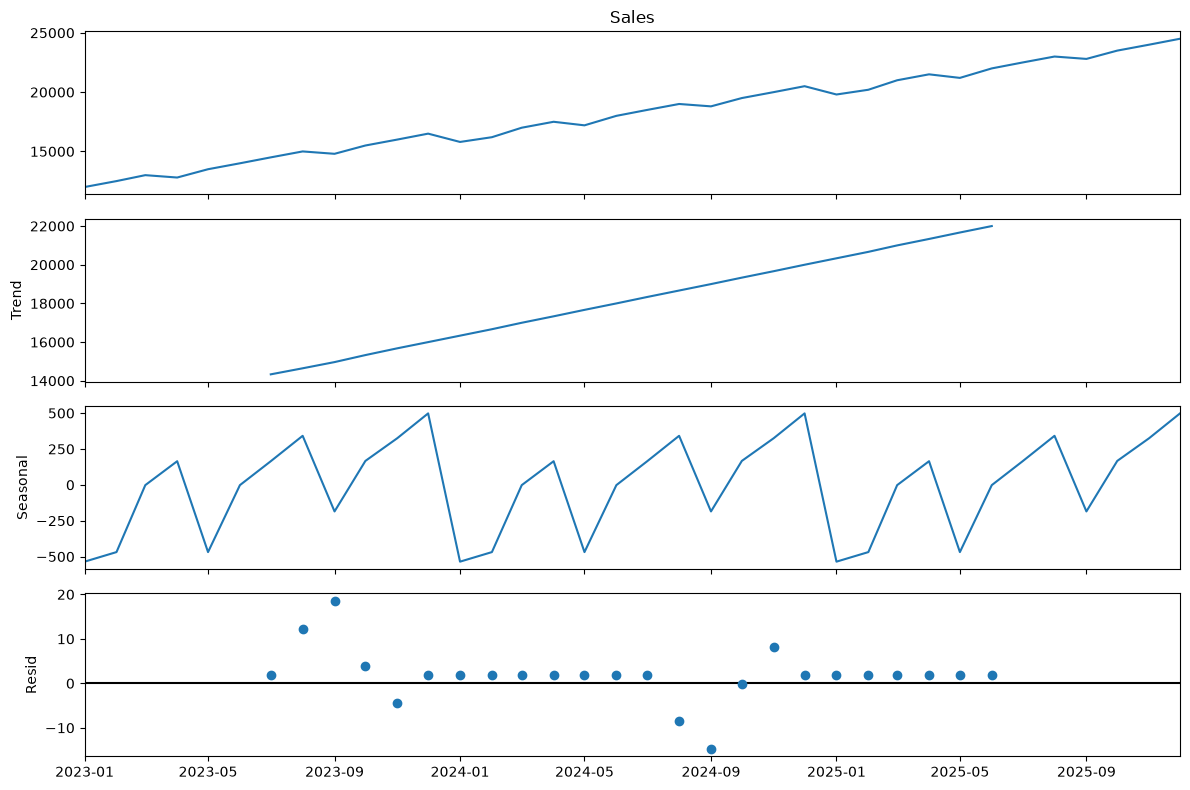

In [57]:
# Step 49 - Time Series Decomposition

from statsmodels.tsa.seasonal import seasonal_decompose

# Decompose the monthly sales series
decomposition = seasonal_decompose(
    sales_df["Sales"],
    model="additive",
    period=12
)

# Plot trend, seasonal and residual components
fig = decomposition.plot()

fig.set_size_inches(12, 8)

plt.tight_layout()
plt.show()

# Final Task 4 Findings

## Statistical Analysis

ANOVA was performed to compare passenger fares across the three passenger classes.

The ANOVA statistic was approximately 242.34 and the p-value was approximately 1.03 × 10⁻⁸⁴. Since the p-value is less than 0.05, there is a statistically significant difference in average fares between passenger classes.

## Time Series Analysis

The time-series decomposition identified an overall upward trend, a repeating seasonal pattern, and residual variation. ARIMA forecasting was also performed and evaluated using MAE, RMSE and MAPE.

The forecast evaluation produced:
- MAE: approximately 2343.50
- RMSE: approximately 2352.60
- MAPE: approximately 10.05%

## Customer Segmentation

K-Means clustering was used to divide the data into five customer/passenger segments. PCA was used to visualize the resulting clusters, and cluster profiles were created using Age, Fare and Passenger Class.

## Predictive Modeling

Two classification models were developed to predict the Survived target:

- Logistic Regression
- Decision Tree

Both models achieved 69.2% accuracy.

Logistic Regression:
- Accuracy: 0.692
- Precision: 0.659
- Recall: 0.500
- F1-Score: 0.569
- ROC-AUC: 0.733

Decision Tree:
- Accuracy: 0.692
- Precision: 0.635
- Recall: 0.569
- F1-Score: 0.600
- ROC-AUC: 0.652

Based on the overall evaluation, Logistic Regression performed better in terms of ROC-AUC and Precision, while the Decision Tree achieved better Recall and F1-Score.

## Limitations

The analysis used a limited set of features for predictive modeling. The dataset is historical and the results may not generalize to other datasets or populations. Model performance could potentially be improved by using additional relevant features, better feature engineering and hyperparameter tuning.